# 3. Compare VED trips to a reference cycle

This notebook compares a batch of real VED trips against a legislated reference cycle (FTP-75, FTP-75, US06, or HWFET) on one descriptor, using energy distance (whole-distribution difference) and TOST (equivalence testing).

**Before running**: obtain a reference-cycle speed trace as a two-column CSV (`time_s`, `speed_kmh`) — see `drivecycle_stats.io_cycles` for public sources, or use `download_epa_cycle` for the US EPA cycles.
import sys
!{sys.executable} -m pip install -e "D:/Claude/Thesis/public_toolkit/drivecycle-stats"

In [8]:
VED_CSV_PATH = "VED_171101_week.csv"
REFERENCE_CYCLE = "FTP75"   # EPA urban cycle; also "US06" or "HWFET"
REFERENCE_CYCLE_TXT = "ftpcol.txt"
N_TRIPS = 100

In [9]:
from drivecycle_stats.descriptors import descriptors_table, trip_descriptors
from drivecycle_stats.io_ved import clean_trip, iter_ved_trips, load_ved_dynamic_csv

raw = load_ved_dynamic_csv(VED_CSV_PATH)
frames = []
for veh_id, trip_id, raw_trip in iter_ved_trips(raw):
    frame, report = clean_trip(raw_trip)
    if frame is not None:
        frames.append(frame)
    if len(frames) >= N_TRIPS:
        break

real_table = descriptors_table(frames)
print(f"{len(real_table)} real trips")

100 real trips


Load the reference cycle. This cell will raise `FileNotFoundError` until you supply `REFERENCE_CYCLE_CSV` — see the note above.

In [10]:
# Downloads once from the EPA site. The saved file is the EPA .txt format
# (tab separated, two header lines, speed in mph), so it is read with
# load_epa_cycle_txt, which converts to km/h.
import os

from drivecycle_stats.io_cycles import download_epa_cycle, load_epa_cycle_txt

if not os.path.exists(REFERENCE_CYCLE_TXT):
    download_epa_cycle(REFERENCE_CYCLE, REFERENCE_CYCLE_TXT)

ref_frame = load_epa_cycle_txt(REFERENCE_CYCLE_TXT)
ref_frame["Acceleration"] = ref_frame["Speed"].diff().fillna(0) / 3.6
ref_descriptors = trip_descriptors(ref_frame)
ref_descriptors

{'distance_km': 17.769437664,
 'duration_s': 1875,
 'avgspd': 34.117320314880004,
 'runspd': 42.38909712286282,
 'avgposacc': 0.6085940594059406,
 'rmsa': 0.6306892117447254,
 'idle_share': 0.1952,
 'n_stops': 24,
 'mean_stop_duration_s': 15.25,
 'v95': 85.98724992,
 'vsp_pos_mean': 5.717885150613909}

Compare average speed distributions with energy distance and a permutation test.

In [11]:
from drivecycle_stats.compare import energy_test, tost

real_avgspd = real_table["avgspd"].dropna().to_numpy()

# energy distance needs two samples; here we compare against a
# small set of repeated reference-cycle draws is not meaningful
# for a single trace, so this compares the real-trip distribution
# to itself split in half as a sanity check. Replace with a real
# second sample (e.g. trips from a different period or vehicle
# class) for an actual comparison.
half = len(real_avgspd) // 2
result = energy_test(real_avgspd[:half], real_avgspd[half:], n_perm=500, seed=0)
print(result["statistic"], result["p_value"])

1.318345067260955 0.08782435129740519


In [12]:
# TOST equivalence check: is the real-trip average speed within
# 5 km/h of the reference cycle's average speed?
bound = 5.0
tost_result = tost(real_avgspd, [ref_descriptors["avgspd"]] * len(real_avgspd), bound=bound)
tost_result

{'p_lower': 1.6346684561518998e-08,
 'p_upper': 0.1338893073903058,
 'p_value': 0.1338893073903058,
 'equivalent': False,
 'mean_difference': 3.4331733079697173}

Plot the distribution against the reference cycle value.

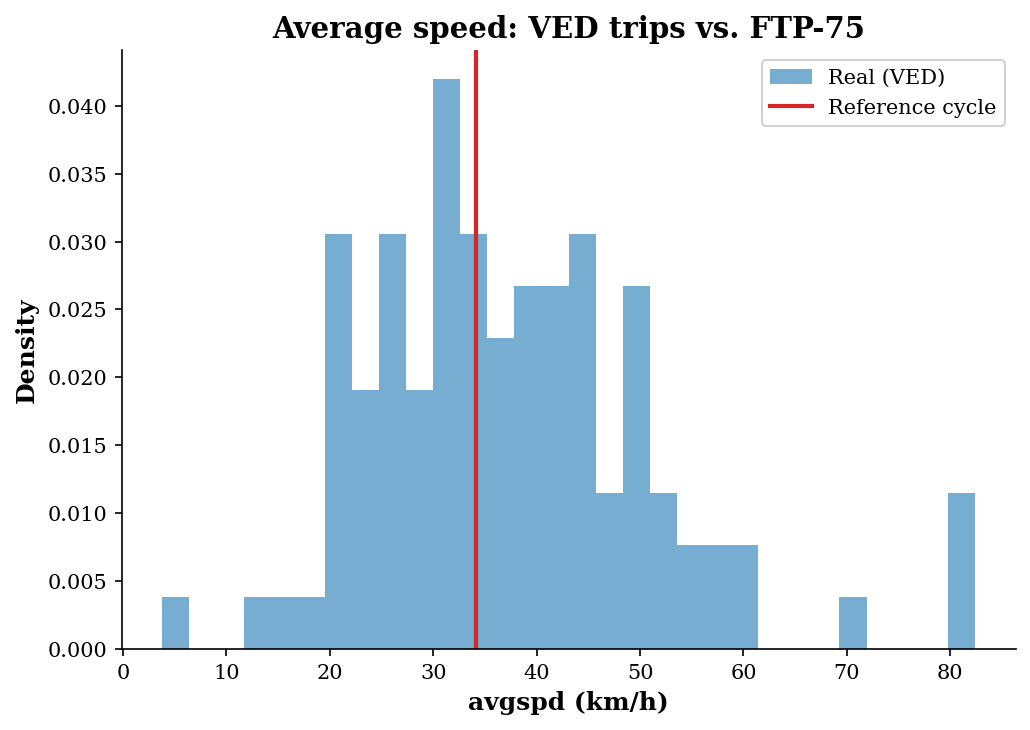

In [13]:
from drivecycle_stats.figures import plot_descriptor_distributions

fig = plot_descriptor_distributions(
    real_avgspd, [ref_descriptors["avgspd"]], "avgspd (km/h)",
    title="Average speed: VED trips vs. FTP-75",
)
fig.savefig("03_avgspd_comparison.png", dpi=600, bbox_inches="tight")